In [128]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
main = pd.read_csv("rankings.csv")
main.columns = main.columns.str.strip()

id_cols = ["country", "population", "gdp_pc", "gender_gap"]
outcome_cols = [col for col in main.columns if col not in id_cols]

main_long = main.melt(
    id_vars=id_cols,
    value_vars=outcome_cols,
    var_name="sport_gender",
    value_name="y_rank",
)
sport_split = main_long["sport_gender"].str.rsplit("_", n=1, expand=True)
main_long["sport"] = sport_split[0]
main_long["gender"] = sport_split[1]
main_long = main_long.drop(columns=["sport_gender"])

trends = pd.read_csv("trends_2006to15.csv")
trends.columns = trends.columns.str.strip()
trends_long = trends.melt(id_vars=["country"], var_name="sport", value_name="w")

long_df = main_long.merge(trends_long, on=["country", "sport"], how="left")
long_df["y_rank"] = pd.to_numeric(long_df["y_rank"], errors="coerce")
long_df.loc[(long_df["y_rank"] <= 0) | (long_df["y_rank"] > 100), "y_rank"] = 101.0
long_df["y_logit"] = ((101 - long_df["y_rank"].clip(1, 100)) / 100).clip(0, 1)
long_df["w"] = pd.to_numeric(long_df["w"], errors="coerce")
long_df = long_df.dropna(subset=["country", "sport", "gender", "y_rank", "y_logit", "w"]).copy()
long_df.head()

,country,population,gdp_pc,gender_gap,y_rank,sport,gender,w,y_logit
0,Brazil,213421037,23310,0.720,6,soccer,m,0.775099,0.95
1,Japan,122950000,54815,0.666,16,soccer,m,0.586810,0.85
2,Germany,83497147,73553,0.803,12,soccer,m,0.598127,0.89
3,France,69081996,66061,0.765,3,soccer,m,0.457850,0.98
4,Thailand,65826149,26359,0.728,101,soccer,m,0.940444,0.01


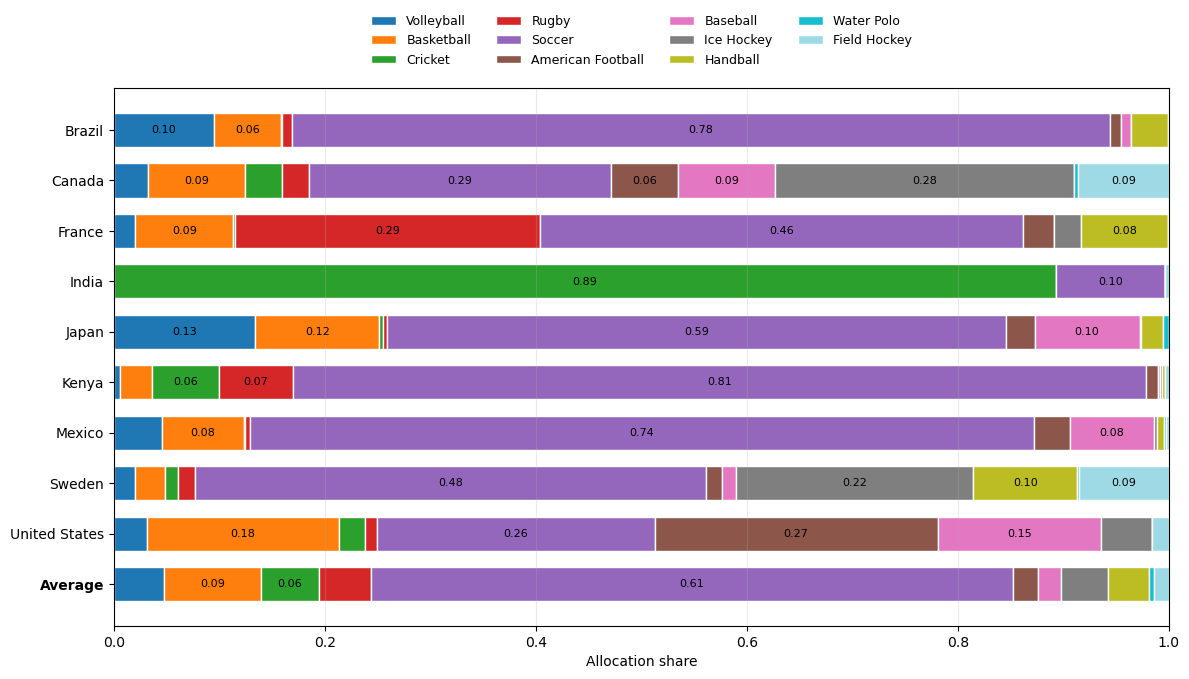

In [ ]:
# 11-sport allocation vectors for selected countries
countries = ["Brazil", "Canada", "France", "India", "Japan", "Kenya", "Mexico", "Sweden", "United States"]

alloc = pd.read_csv("trends_2006to15.csv")
alloc.columns = alloc.columns.str.strip()
sport_cols = [c for c in alloc.columns if c != "country"]

plot_alloc = alloc[alloc["country"].isin(countries)].copy()
plot_alloc = plot_alloc.set_index("country")[sport_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
plot_alloc = plot_alloc.div(plot_alloc.sum(axis=1), axis=0)
plot_alloc = plot_alloc.reindex(countries)

avg_row = alloc[sport_cols].apply(pd.to_numeric, errors="coerce").mean().fillna(0.0)
avg_row = avg_row / avg_row.sum()
plot_alloc.loc["Average"] = avg_row

sport_labels = [s.replace("_", " ").title() for s in sport_cols]
colors = plt.cm.tab20(np.linspace(0, 1, len(sport_cols)))
fig, ax = plt.subplots(figsize=(12, 7.5))

left = np.zeros(len(plot_alloc))
for sport, sport_label, color in zip(sport_cols, sport_labels, colors):
    vals = plot_alloc[sport].to_numpy()
    ax.barh(plot_alloc.index, vals, left=left, color=color, 
            edgecolor="white", height=0.68, label=sport_label)

    for i, v in enumerate(vals):
        if v > 0.05:
            ax.text(left[i] + v / 2, i, f"{v:.2f}",
                ha="center", va="center", fontsize=8, color="black")

    left += vals

ax.set_xlim(0, 1)
ax.set_xlabel("Allocation share")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

for lbl in ax.get_yticklabels():
    if lbl.get_text() == "Average":
        lbl.set_fontweight("bold")

ax.legend(title="", loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=4, frameon=False, fontsize=9)

fig_alloc = fig
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [135]:
sample = long_df[["country", "sport", "gender", "y_rank", "y_logit", "population", "gdp_pc", "w"]].copy()

sample["log_pop"] = np.log(pd.to_numeric(sample["population"], errors="coerce"))
sample["log_gdp_pc"] = np.log(pd.to_numeric(sample["gdp_pc"], errors="coerce"))
sample["log_w"] = np.log(pd.to_numeric(sample["w"], errors="coerce") + 1e-3)

sample = sample.dropna(subset=["y_rank", "y_logit", "log_pop", "log_gdp_pc", "log_w"]).copy()
sample["log_w_c_sport"] = sample["log_w"] - sample.groupby("sport")["log_w"].transform("mean")

model_specs = [
    ("pop_gdp_only", ["log_pop", "log_gdp_pc"]),
    ("plus_w_centered_by_sport", ["log_pop", "log_gdp_pc", "log_w_c_sport"]),
]

def fit_fractional_logit(data, predictors):
    X = sm.add_constant(data[predictors], has_constant="add")
    y = data["y_logit"].astype(float)
    return sm.GLM(y, X, family=sm.families.Binomial()).fit()

frac_fits = {}
comparison_rows = []

for model_name, predictors in model_specs:
    model_data = sample.dropna(subset=predictors).copy()
    fit = fit_fractional_logit(model_data, predictors)
    frac_fits[model_name] = fit

    pseudo_r2 = np.nan if fit.llnull == 0 else 1 - (fit.llf / fit.llnull)
    comparison_rows.append(
        {
            "model": model_name,
            "nobs": int(fit.nobs),
            "aic": fit.aic,
            "pseudo_r2_mcfadden": pseudo_r2,
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("aic").reset_index(drop=True)
print(comparison.round(6))

                      model  nobs         aic  pseudo_r2_mcfadden
0  plus_w_centered_by_sport   400  387.088008            0.126844
1              pop_gdp_only   400  416.566041            0.054341


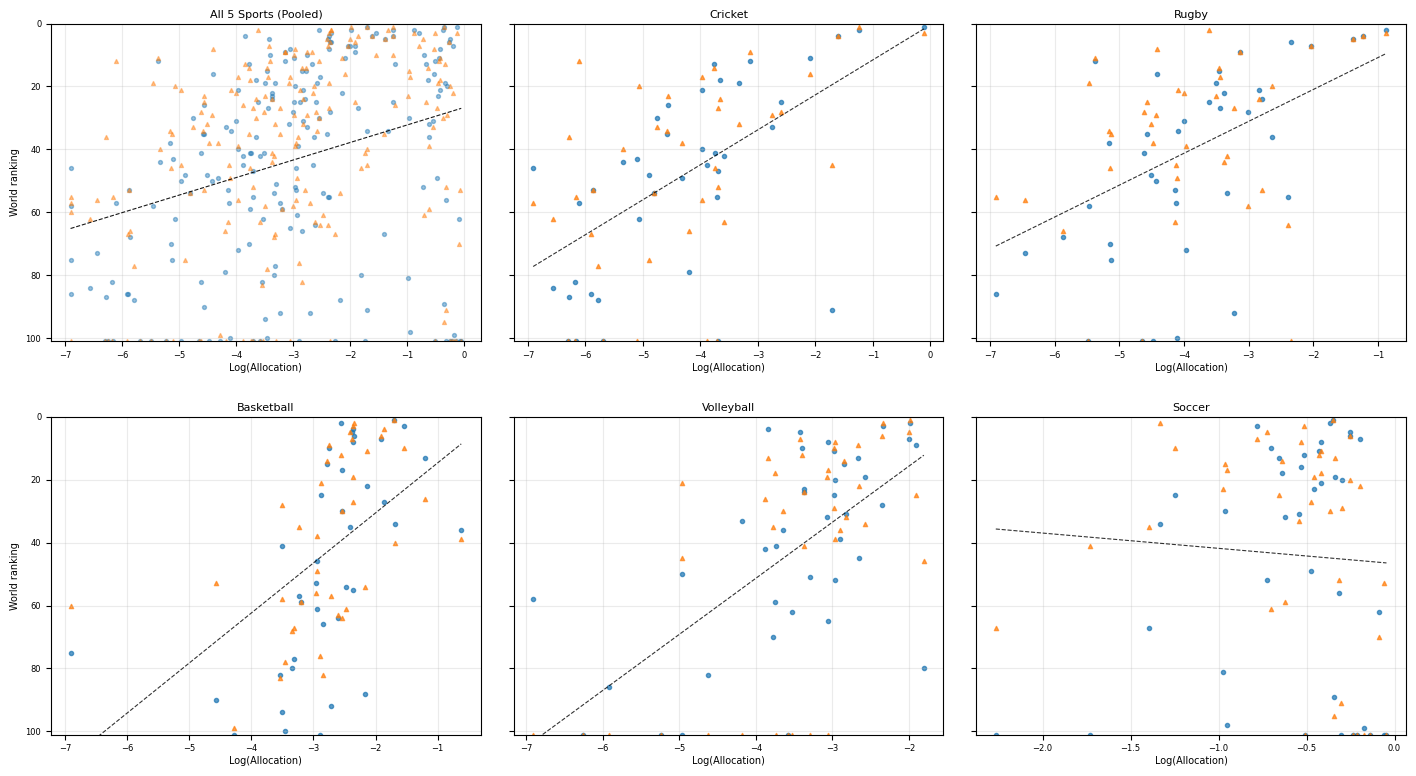

In [136]:
# Rank vs allocation per sport, split by gender
sports5 = ["soccer", "basketball", "volleyball", "cricket", "rugby"]
sports_plot_order = ["cricket", "rugby", "basketball", "volleyball", "soccer"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.6), sharey=True, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.06, hspace=0.08)
axes_flat = axes.flatten()

# 1st panel: pooled data across all five sports with one overall regression line
ax_all = axes_flat[0]
d_all = sample[sample["sport"].isin(sports5)]
d_all_m = d_all[d_all["gender"] == "m"]
d_all_w = d_all[d_all["gender"] == "w"]
ax_all.scatter(d_all_m["log_w"], d_all_m["y_rank"], alpha=0.45, s=8, marker="o")
ax_all.scatter(d_all_w["log_w"], d_all_w["y_rank"], alpha=0.45, s=8, marker="^")

if len(d_all) >= 2:
    xline_all = np.linspace(d_all["log_w"].min(), d_all["log_w"].max(), 150)
    slope_all, intercept_all = np.polyfit(d_all["log_w"], d_all["y_rank"], 1)
    yline_all = slope_all * xline_all + intercept_all
    ax_all.plot(xline_all, yline_all, color="black", linewidth=0.8, alpha=0.9, linestyle="--")

ax_all.set_title("All 5 Sports (Pooled)", fontsize=8, pad=4)
ax_all.set_xlabel("Log(Allocation)", fontsize=7, labelpad=2)
ax_all.set_ylabel("World ranking", fontsize=7)
ax_all.set_ylim(101, 0)
ax_all.tick_params(axis="both", labelsize=6)
ax_all.grid(alpha=0.25)

# Remaining panels: sport-specific plots in requested dramatic order
for panel_idx, sport in enumerate(sports_plot_order, start=1):
    ax = axes_flat[panel_idx]
    d = sample[sample["sport"] == sport]
    d_m = d[d["gender"] == "m"]
    d_w = d[d["gender"] == "w"]
    ax.scatter(d_m["log_w"], d_m["y_rank"], alpha=0.72, s=9, marker="o")
    ax.scatter(d_w["log_w"], d_w["y_rank"], alpha=0.72, s=9, marker="^")

    if len(d) >= 2:
        xline = np.linspace(d["log_w"].min(), d["log_w"].max(), 100)
        slope, intercept = np.polyfit(d["log_w"], d["y_rank"], 1)
        yline = slope * xline + intercept
        ax.plot(xline, yline, color="black", linewidth=0.8, alpha=0.8, linestyle="--")

    ax.set_title(sport.title(), fontsize=8, pad=4)
    ax.set_xlabel("Log(Allocation)", fontsize=7, labelpad=2)
    if panel_idx % 3 == 0:
        ax.set_ylabel("World ranking", fontsize=7)
    ax.set_ylim(101, 0)
    ax.tick_params(axis="both", labelsize=6)
    ax.grid(alpha=0.25)

fig_sports5 = fig
plt.show()


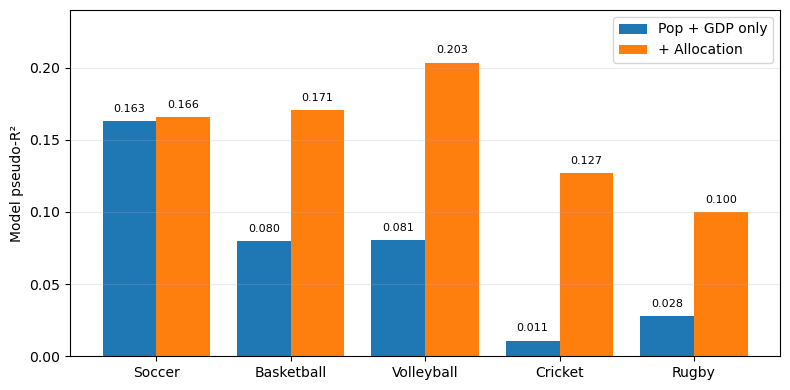

In [ ]:
rows = []
for sport in sports5:
    d = sample[sample["sport"] == sport].dropna(subset=["y_logit", "log_pop", "log_gdp_pc", "log_w_c_sport"]).copy()
    fit_b = fit_fractional_logit(d, ["log_pop", "log_gdp_pc"])
    fit_w = fit_fractional_logit(d, ["log_pop", "log_gdp_pc", "log_w_c_sport"])
    rows.append({
        "sport": sport,
        "r2_base": 1 - fit_b.llf / fit_b.llnull,
        "r2_plus_w": 1 - fit_w.llf / fit_w.llnull,
        "delta_r2": (1 - fit_w.llf / fit_w.llnull) - (1 - fit_b.llf / fit_b.llnull),
    })

r2_table = pd.DataFrame(rows)

x = np.arange(len(sports5))
fig, ax = plt.subplots(figsize=(8, 4))
bars_base = ax.bar(x - 0.2, r2_table["r2_base"], width=0.4, label="Pop + GDP only")
bars_plus_w = ax.bar(x + 0.2, r2_table["r2_plus_w"], width=0.4, label="+ Allocation")
ax.set_ylim(0, 0.24)

for bars in (bars_base, bars_plus_w):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in sports5])
ax.set_ylabel("Model pseudo-R²")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig_r2 = fig
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
blog_visuals = Path("../visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

def export_figure(fig, filename, width_px=1200, aspect=0.56, dpi=220, transparent=False, 
                  title_fs=10, label_fs=9, tick_fs=8, reset_fonts=True, tight=True, pad_inches=0.08):
    out = blog_visuals / filename
    fig_w = width_px / dpi
    fig_h = (width_px * aspect) / dpi
    fig.set_size_inches(fig_w, fig_h)

    if reset_fonts:
        for ax in fig.axes:
            ax.title.set_fontsize(title_fs)
            ax.xaxis.label.set_fontsize(label_fs)
            ax.yaxis.label.set_fontsize(label_fs)
            ax.tick_params(axis="both", labelsize=tick_fs)

    bbox = "tight" if tight else None
    fig.savefig(out, dpi=dpi, bbox_inches=bbox, pad_inches=pad_inches, transparent=transparent)
    print(f"Saved figure: {out.resolve()}")
    return out

def md_image(path, display_width_px=680):
    rel = path.relative_to(blog_visuals.parent)
    print(f"<img src=\"{rel.as_posix()}\" width=\"{display_width_px}\" />")

alloc_path = export_figure(fig_alloc, "allocation-vectors.png", aspect=0.62)
sports5_path = export_figure(fig_sports5, "sports5.png", width_px=1400, aspect=0.54, 
                             reset_fonts=False, tight=False, pad_inches=0.04)
r2_plot_path = export_figure(fig_r2, "r2-by-sport.png", aspect=0.52)

md_image(alloc_path)
md_image(sports5_path)
md_image(r2_plot_path)

Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.03 National Teams/visuals/allocation-vectors.png
Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.03 National Teams/visuals/sports5.png
Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.03 National Teams/visuals/r2-by-sport.png
<img src="visuals/allocation-vectors.png" width="680" />
<img src="visuals/sports5.png" width="680" />
<img src="visuals/r2-by-sport.png" width="680" />
